In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\death\MyPython\ecommerce-behavior-data-from-multi-category-stor\2019-Nov.csv", sep = ",")


print(df.shape)
df.head(5)

(67501979, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [2]:
df.columns

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')

In [3]:
df["event_type"].value_counts()

event_type
view        63556110
cart         3028930
purchase      916939
Name: count, dtype: int64

In [4]:
df_small = df.sample(n = 200000, random_state = 42).copy()
df_small.shape

(200000, 9)

In [5]:
user_product = pd.crosstab(
    index = [df_small["user_id"], df_small["product_id"]],
    columns = df_small["event_type"]
)

user_product.head()

,event_type,cart,purchase,view
user_id,product_id,,,
110760953,100011674,0,0,1
192078182,3701005,1,0,0
210089363,16700262,0,0,1
213763705,3701340,0,0,1
249526511,12701623,0,0,1


In [6]:
user_product = user_product.reset_index()

In [7]:
if "purchase" not in user_product.columns:
    user_product["purchase"] = 0

if "view" not in user_product.columns:
    user_product["view"] = 0

if "cart" not in user_product.columns:
    user_product["cart"] = 0

user_product["label"] = (user_product["purchase"] > 0).astype(int)

print(user_product.head())
print(user_product["label"].value_counts())
print(user_product["label"].value_counts(normalize = True))

event_type    user_id  product_id  cart  purchase  view  label
0           110760953   100011674     0         0     1      0
1           192078182     3701005     1         0     0      0
2           210089363    16700262     0         0     1      0
3           213763705     3701340     0         0     1      0
4           249526511    12701623     0         0     1      0
label
0    196067
1      2669
Name: count, dtype: int64
label
0    0.98657
1    0.01343
Name: proportion, dtype: float64


In [8]:
X = user_product[["view", "cart"]]
y = user_product["label"]

print(X.head())
print("-" * 50)
print(y.head())

event_type  view  cart
0              1     0
1              0     1
2              1     0
3              1     0
4              1     0
--------------------------------------------------
0    0
1    0
2    0
3    0
4    0
Name: label, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify = y
)

print(X_train.shape, X_test.shape)
print("-" * 50)
print(y_train.value_counts(normalize=True))
print("-" * 50)
print(y_test.value_counts(normalize=True))

(158988, 2) (39748, 2)
--------------------------------------------------
label
0    0.986571
1    0.013429
Name: proportion, dtype: float64
--------------------------------------------------
label
0    0.986565
1    0.013435
Name: proportion, dtype: float64


### <font color = "blue">LogisticRegression</font>

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight = "balanced", max_iter = 1000) #class_weight解決資料不平衡。 max_iter 調整模型訓練的迭代次數
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(39748,))

[[TN  FP]\
 [FN  TP]]

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print("-" * 50)
print(classification_report(y_test, y_pred))

[[39214     0]
 [   24   510]]
--------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39214
           1       1.00      0.96      0.98       534

    accuracy                           1.00     39748
   macro avg       1.00      0.98      0.99     39748
weighted avg       1.00      1.00      1.00     39748



### 時間切分版本 Purchase Prediction

### 先轉換event_time

In [12]:
df["event_time"]=pd.to_datetime(df["event_time"])
df["event_time"].min(), df["event_time"].max()

(Timestamp('2019-11-01 00:00:00+0000', tz='UTC'),
 Timestamp('2019-11-30 23:59:59+0000', tz='UTC'))

### 先用小樣本練習

In [13]:
df_small_time=df.sample(n=500000, random_state=42).copy()

df_small_time["event_time"]=pd.to_datetime(df_small_time["event_time"])

print(df_small_time["event_time"].min())
print(df_small_time["event_time"].max())

2019-11-01 00:00:50+00:00
2019-11-30 23:59:59+00:00


### 設定時間切分點

In [14]:
split_date="2019-11-21"

past_df=df_small_time[df_small_time["event_time"] < split_date].copy()
future_df=df_small_time[df_small_time["event_time"] >= split_date].copy()

print(past_df.shape)
print(future_df.shape)

(377016, 9)
(122984, 9)


### 用past_df建立特徵X

In [15]:
X_table = pd.crosstab(
    index=[past_df["user_id"], past_df["product_id"]],
    columns=past_df["event_type"]
).reset_index()

if "view" not in X_table.columns:
    X_table["view"]=0

if "cart" not in X_table.columns:
    X_table["cart"]=0

X_table=X_table[["user_id", "product_id", "view" , "cart"]]

X_table.head()

event_type,user_id,product_id,view,cart
0,110760953,100011674,1,0
1,149382035,17200858,1,0
2,158367814,26500606,1,0
3,197647707,28721201,1,0
4,210089363,13300174,1,0


### 用future_df建立答案y

In [16]:
future_purchase=future_df[future_df["event_type"] == "purchase"]


y_table=future_purchase.groupby(
    ["user_id", "product_id"]
).size().reset_index(name = "future_purchase_count")

y_table["label"] = 1

y_table.head()

,user_id,product_id,future_purchase_count,label
0,450121457,1200947,1,1
1,457745111,12710985,1,1
2,512369878,1306948,1,1
3,512371142,26400280,1,1
4,512372673,4803879,1,1


### 把X和y合併

In [17]:
model_df= X_table.merge(
    y_table[["user_id", "product_id", "label"]],
    on = ["user_id", "product_id"],
    how="left"
)

model_df["label"]=model_df["label"].fillna(0).astype(int)

model_df.head()

,user_id,product_id,view,cart,label
0,110760953,100011674,1,0,0
1,149382035,17200858,1,0,0
2,158367814,26500606,1,0,0
3,197647707,28721201,1,0,0
4,210089363,13300174,1,0,0


### 檢查新label分佈

In [18]:
print(model_df["label"].value_counts())
print(model_df["label"].value_counts(normalize=True))

label
0    371463
1        21
Name: count, dtype: int64
label
0    0.999943
1    0.000057
Name: proportion, dtype: float64


In [19]:
print(model_df.info())
print(model_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371484 entries, 0 to 371483
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   user_id     371484 non-null  int64
 1   product_id  371484 non-null  int64
 2   view        371484 non-null  int64
 3   cart        371484 non-null  int64
 4   label       371484 non-null  int64
dtypes: int64(5)
memory usage: 14.2 MB
None
     user_id  product_id  view  cart  label
0  110760953   100011674     1     0      0
1  149382035    17200858     1     0      0
2  158367814    26500606     1     0      0
3  197647707    28721201     1     0      0
4  210089363    13300174     1     0      0


In [20]:
int_cols=model_df.select_dtypes(include=["int64"]).columns

model_df[int_cols]=model_df[int_cols].apply(pd.to_numeric, downcast="integer")

# model_df[int_cols] = model_df[int_cols].apply(
#     pd.to_numeric,
#     downcast="integer"
# )

model_df

,user_id,product_id,view,cart,label
0,110760953,100011674,1,0,0
1,149382035,17200858,1,0,0
2,158367814,26500606,1,0,0
3,197647707,28721201,1,0,0
4,210089363,13300174,1,0,0
...,...,...,...,...,...
371479,574160409,1004155,1,0,0
371480,574161584,1005161,1,0,0
371481,574164272,10300835,1,0,0
371482,574165925,10300496,1,0,0


In [21]:
X=model_df[["view", "cart"]]
y=model_df["label"]

### 進行train, text切分

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
)

print(X_train.shape)
print(y_train.shape)
print("================")
print(X_test.shape)
print(y_test.shape)

(297187, 2)
(297187,)
(74297, 2)
(74297,)


In [23]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)


model.fit(X_train, y_train)

y_pred=model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(74297,), dtype=int8)

In [24]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[69969  4324]
 [    3     1]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     74293
           1       0.00      0.25      0.00         4

    accuracy                           0.94     74297
   macro avg       0.50      0.60      0.49     74297
weighted avg       1.00      0.94      0.97     74297



### 模型解析

模型只抓到1筆真的購買
- TN = 69969
- PN = 4324

但模型誤判很多人會買
- FN = 3
- TP = 1

accuracy = 0.94
因為0類太多，模型大部分都猜「沒買」，accuracy就會變很好看
所以不平衡的分類不能單看accuracy


<center>label=1</center>

|指標|你的結果|解讀|
| :---: | :---: | :---: |
|precision|0.00|預測會買的人幾乎都沒買
|recall|0.25|真正會買的人只抓到 25%
|f1-score|0.00|整體對購買預測很差

總結\
真的未來會購買的user只有4筆\
但表示用時間切分+抽樣方式下，正樣本太稀疏(特徵太少、會購買的資料太少)\
這個baseline 不能用來預測購買

### 新增特徵 has_cart (過去有加過購物車)

In [25]:
model_df["has_cart"] = (model_df["cart"] > 0).astype(int)

X = model_df[["view", "cart", "has_cart"]].copy()
y = model_df["label"].copy()

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
)

model=LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train, y_train)

y_pred=model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[70008  4285]
 [    3     1]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     74293
           1       0.00      0.25      0.00         4

    accuracy                           0.94     74297
   macro avg       0.50      0.60      0.49     74297
weighted avg       1.00      0.94      0.97     74297



### 把熱門商品加總、商品平均價格加進來當作特徵

In [27]:
product_features = past_df.groupby("product_id").agg(
    product_view_count=("event_type", lambda x: (x == "view").sum()),
    product_cart_count=("event_type", lambda x: (x == "cart").sum()),
    product_action_count=("event_type", "count"),
    product_avg_price=("price", "mean")
).reset_index()

model_df = model_df.merge(
    product_features,
    on="product_id",
    how="left"
)

model_df.head()

,user_id,product_id,view,cart,label,has_cart,product_view_count,product_cart_count,product_action_count,product_avg_price
0,110760953,100011674,1,0,0,0,9,0,9,388.971111
1,149382035,17200858,1,0,0,0,1,0,1,979.430000
2,158367814,26500606,1,0,0,0,4,0,4,855.440000
3,197647707,28721201,1,0,0,0,1,1,2,89.840000
4,210089363,13300174,1,0,0,0,74,2,76,154.190000


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

X = model_df[
    [
        "view",
        "cart",
        "has_cart",
        "product_view_count",
        "product_cart_count",
        "product_action_count",
        "product_avg_price",
    ]
].fillna(0).copy()

y = model_df["label"].copy()


X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
)

model=LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train, y_train)

y_pred=model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[68676  5617]
 [    3     1]]
              precision    recall  f1-score   support

           0       1.00      0.92      0.96     74293
           1       0.00      0.25      0.00         4

    accuracy                           0.92     74297
   macro avg       0.50      0.59      0.48     74297
weighted avg       1.00      0.92      0.96     74297



### 調整資料樣本 放大實際有購買的user

In [29]:
#轉時間
df["event_time"] = pd.to_datetime(df["event_time"])

#找出有purchase的user
purchase_users = df.loc[
    df["event_type"] == "purchase",
    "user_id"
].drop_duplicates()

#抽一部分有購買的user
sample_users = purchase_users.sample(
    n=50000,
    random_state=42
)

#保留這些user所有行為
df_sample_user = df[df["user_id"].isin(sample_users)].copy()

print(df_sample_user.shape)
print(df_sample_user["event_type"].value_counts())

(2662369, 9)
event_type
view        2339180
cart         219696
purchase     103493
Name: count, dtype: int64


In [30]:
df_small_time=df_sample_user.copy()

df_small_time["event_time"]=pd.to_datetime(df_small_time["event_time"])

print(df_small_time["event_time"].min())
print(df_small_time["event_time"].max())

2019-11-01 00:00:16+00:00
2019-11-30 23:59:53+00:00


In [31]:
split_date = "2019-11-21"

past_df=df_sample_user[df_sample_user["event_time"] < split_date].copy()
future_df=df_sample_user[df_sample_user["event_time"] >= split_date].copy()

print("past_df:",past_df.shape)
print("future_df:",future_df.shape)
print("=" * 30)
print("past event:")
print(past_df["event_type"].value_counts())
print("=" * 30)
print("future event:")
print(future_df["event_type"].value_counts())

past_df: (2067303, 9)
future_df: (595066, 9)
past event:
event_type
view        1831358
cart         160759
purchase      75186
Name: count, dtype: int64
future event:
event_type
view        507822
cart         58937
purchase     28307
Name: count, dtype: int64


In [32]:
#用past_df建立特徵
X_table = pd.crosstab(
    index=[past_df["user_id"], past_df["product_id"]],
    columns=past_df["event_type"]
).reset_index()

#補欄位 debug 避免缺少view/cart
if "view" not in X_table.columns:
    X_table["view"] = 0

if "cart" not in X_table.columns:
    X_table["cart"] = 0

#保留要用的欄位
X_table = X_table[["user_id", "product_id", "view", "cart"]]

#用future建立未來購買的label
future_purchase = future_df[future_df["event_type"] == "purchase"]

y_table = future_purchase.groupby(["user_id", "product_id"]).size().reset_index(name="future_purchase_count")

y_table["label"] = 1

#合併 X_table, y_table
model_df = X_table.merge(
    y_table[["user_id", "product_id", "label"]],
    on=["user_id", "product_id"],
    how="left"
)

model_df["label"] = model_df["label"].fillna(0).astype(int)

print(model_df.shape)
print(model_df.head())
print(model_df["label"].value_counts())
print(model_df["label"].value_counts(normalize=True))

(864471, 5)
     user_id  product_id  view  cart  label
0  138340325    17300771     1     0      0
1  138340325    17300789     1     0      0
2  138340325    17301041     1     0      0
3  138340325    17301868     1     0      0
4  307574312    16000546     1     1      0
label
0    860131
1      4340
Name: count, dtype: int64
label
0    0.99498
1    0.00502
Name: proportion, dtype: float64


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report


X = model_df[["view", "cart"]].copy()
y = model_df["label"].copy()


X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
)

model=LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train, y_train)

y_pred=model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[152779  19248]
 [   361    507]]
              precision    recall  f1-score   support

           0       1.00      0.89      0.94    172027
           1       0.03      0.58      0.05       868

    accuracy                           0.89    172895
   macro avg       0.51      0.74      0.49    172895
weighted avg       0.99      0.89      0.94    172895



In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_proba = model.predict_proba(X_test)[:, 1] #這會輸出模型判斷每筆資料屬於各0,1「機率」

for threshold in [0.3, 0.5, 0.7, 0.9]:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    print("threshold:", threshold)
    print("precision:", precision_score(y_test, y_pred_threshold, zero_division=0))
    print("recall:", recall_score(y_test, y_pred_threshold, zero_division=0))
    print("f1:", f1_score(y_test, y_pred_threshold, zero_division=0))
    print("-" * 30)

threshold: 0.3
precision: 0.005020388096821771
recall: 1.0
f1: 0.009990619406893298
------------------------------
threshold: 0.5
precision: 0.025664388762338647
recall: 0.5841013824884793
f1: 0.049168404208892985
------------------------------
threshold: 0.7
precision: 0.03788334335538184
recall: 0.3629032258064516
f1: 0.06860503103560928
------------------------------
threshold: 0.9
precision: 0.055952380952380955
recall: 0.21658986175115208
f1: 0.08893093661305582
------------------------------


### 整理出高機率購買名單

In [35]:
# 先複製一份X_test 避免改到原本資料
result_df = X_test.copy()

# 加回真實答案
result_df["true_label"] = y_test.values

# 加入模型預測購買率
result_df["purchase_proba"] = y_proba

result_df["proba_label"] = (result_df["purchase_proba"] >= 0.9).astype(int)
result_df

,view,cart,true_label,purchase_proba,proba_label
841530,7,1,0,0.714881,0
736652,2,0,0,0.364155,0
833838,1,0,0,0.336740,0
373149,1,0,0,0.336740,0
490907,2,0,0,0.364155,0
...,...,...,...,...,...
261544,3,1,0,0.607616,0
422567,2,0,0,0.364155,0
297984,1,0,0,0.336740,0
130818,6,0,0,0.481142,0


In [36]:
feature_cols = ["view", "cart"]

X = model_df[feature_cols].copy()
y = model_df["label"].copy()

meta = model_df[["user_id", "product_id"]].copy()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X, y, meta,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_proba

array([0.71488117, 0.36415451, 0.33674033, ..., 0.33674033, 0.48114174,
       0.33674033], shape=(172895,))

In [38]:
result_df = meta_test.copy()

result_df["view"] = X_test["view"].values
result_df["cart"] = X_test["cart"].values
result_df["true_label"] = y_test.values
result_df["purchase_proba"] = y_proba
result_df["pred_label"] = (result_df["purchase_proba"] >= 0.9).astype(int)

result_df.head()

,user_id,product_id,view,cart,true_label,purchase_proba,pred_label
841530,571953427,1801766,7,1,0,0.714881,0
736652,563998576,1305005,2,0,0,0.364155,0
833838,571728900,1305864,1,0,0,0.336740,0
373149,521232213,28102095,1,0,0,0.336740,0
490907,535339094,12400252,2,0,0,0.364155,0


In [39]:
high_prob_df = result_df[result_df["pred_label"] == 1].sort_values(
    "purchase_proba",
    ascending=False
)

high_prob_df.head(20)

,user_id,product_id,view,cart,true_label,purchase_proba,pred_label
281238,517061199,2601983,13,55,0,1.0,1
329276,518867808,1005100,25,42,0,1.0,1
313175,518479974,8500288,9,54,0,1.0,1
419046,525610746,1005161,0,61,0,1.0,1
627023,551541889,1005122,11,59,0,1.0,1
108028,513469414,1002544,5,41,0,1.0,1
646282,553532053,31501171,17,38,0,1.0,1
511536,537971942,1004249,41,34,0,1.0,1
813277,569975305,28600032,11,38,0,1.0,1
603537,548669669,1004903,35,34,0,1.0,1


上述跑完結果 purchase_proba = 1.0 ， 但true_label = 0?

表示模型非常自信地預測一定為買，但實際未來沒有真的買

- 原因特徵量太少，目前只有view,cart，只要cart很高->幾乎就會判別一定會買
- Logistic Regression 沒有標準化
- class_weight="balanced" 會讓模型更積極去預測1，主因正樣本數量太少

### 將特徵進行標準化，再跑一次

In [47]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
    )
)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.9).astype(int)

print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred))
print("\n classification_report:")
print(classification_report(y_test, y_pred))

confusion_matrix:
[[168855   3172]
 [   680    188]]

 classification_report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    172027
           1       0.06      0.22      0.09       868

    accuracy                           0.98    172895
   macro avg       0.53      0.60      0.54    172895
weighted avg       0.99      0.98      0.98    172895



In [49]:
model_df["label"].value_counts()

label
0    860131
1      4340
Name: count, dtype: int64

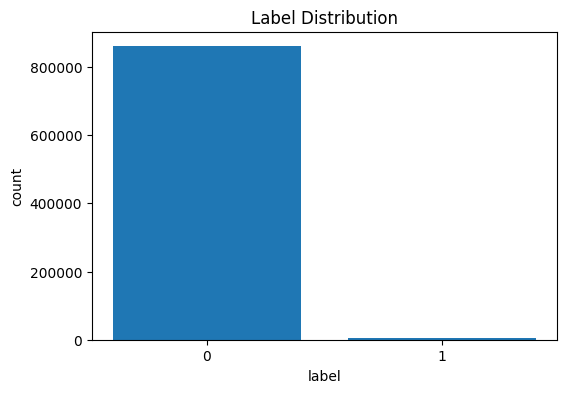

In [54]:
import matplotlib.pyplot as plt

label_counts = model_df["label"].value_counts().sort_index()

plt.figure(figsize = (6, 4))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.xlabel("label")
plt.ylabel("count")
plt.title("Label Distribution")
plt.savefig("Label_Distribution.png", dpi = 200, bbox_inches="tight")
plt.show()